# 🧠 Student Mental Health Risk Prediction System
## Model Training Notebook

**Project:** OJT – Student Mental Health Risk Prediction System  
**Author:** Yug Ramoliya  
**Stack:** scikit-learn, SHAP, MLflow, Pandas  

---

### 📋 Notebook Overview
This notebook covers the full ML pipeline:
1. Data Loading & Preprocessing
2. Feature Engineering
3. Risk Label Creation (Low / Moderate / High)
4. Model Training (Logistic Regression + Random Forest)
5. Model Evaluation (F1, Recall, Confusion Matrix)
6. SHAP Explainability
7. MLflow Experiment Tracking
8. Model Export & Deployment Pipeline

---
## 📦 Section 1: Install & Import Dependencies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os
import json

warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
    accuracy_score, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight

# SHAP
import shap

# MLflow
import mlflow
import mlflow.sklearn

print("✅ All dependencies loaded successfully!")

✅ All dependencies loaded successfully!


---
## 📂 Section 2: Load & Explore Data

In [4]:
# Load dataset
df = pd.read_csv('../dataset/Raw Data.csv')

print(f"📊 Dataset Shape: {df.shape}")

📊 Dataset Shape: (1977, 39)


In [5]:
df.head(5)

,1. Age,2. Gender,3. University,4. Department,5. Academic Year,6. Current CGPA,7. Did you receive a waiver or scholarship at your university?,"1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure?","2. In a semester, how often have you been unable to stop worrying about your academic affairs?","3. In a semester, how often have you had trouble relaxing due to academic pressure?",...,"2. In a semester, how often have you been feeling down, depressed or hopeless?","3. In a semester, how often have you had trouble falling or staying asleep, or sleeping too much?","4. In a semester, how often have you been feeling tired or having little energy?","5. In a semester, how often have you had poor appetite or overeating?","6. In a semester, how often have you been feeling bad about yourself - or that you are a failure or have let yourself or your family down?","7. In a semester, how often have you been having trouble concentrating on things, such as reading the books or watching television?","8. In a semester, how often have you moved or spoke too slowly for other people to notice? Or you've been moving a lot more than usual because you've been restless?","9. In a semester, how often have you had thoughts that you would be better off dead, or of hurting yourself?",Depression Value,Depression Label
0,18-22,Female,"Independent University, Bangladesh (IUB)",Engineering - CS / CSE / CSC / Similar to CS,Fourth Year or Equivalent,2.50 - 2.99,No,1,1,1,...,2,1,1,2,1,1,1,1,11,Moderate Depression
1,18-22,Male,"Independent University, Bangladesh (IUB)",Engineering - CS / CSE / CSC / Similar to CS,First Year or Equivalent,3.80 - 4.00,No,2,2,1,...,1,1,1,1,1,1,1,1,9,Mild Depression
2,18-22,Male,"Independent University, Bangladesh (IUB)",Engineering - CS / CSE / CSC / Similar to CS,First Year or Equivalent,3.00 - 3.39,No,2,1,1,...,0,2,3,2,2,2,2,1,16,Moderately Severe Depression
3,18-22,Male,"Independent University, Bangladesh (IUB)",Engineering - CS / CSE / CSC / Similar to CS,First Year or Equivalent,3.40 - 3.79,No,2,1,1,...,1,1,1,1,1,1,1,1,9,Mild Depression
4,18-22,Male,"Independent University, Bangladesh (IUB)",Engineering - CS / CSE / CSC / Similar to CS,First Year or Equivalent,3.40 - 3.79,No,1,1,1,...,1,1,1,1,1,1,1,1,9,Mild Depression


In [6]:
print("=" * 60)
print("📋 DATA INFO")
print("=" * 60)
df.info()
print("\n📌 Missing Values:")
print(df.isnull().sum())

📋 DATA INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1977 entries, 0 to 1976
Data columns (total 39 columns):
 #   Column                                                                                                                                                                 Non-Null Count  Dtype 
---  ------                                                                                                                                                                 --------------  ----- 
 0   1. Age                                                                                                                                                                 1977 non-null   object
 1   2. Gender                                                                                                                                                              1977 non-null   object
 2   3. University                                                                                   

In [7]:
# Check label distributions
print("📊 Anxiety Labels:")
print(df['Anxiety Label'].value_counts())

print("\n📊 Stress Labels:")
print(df['Stress Label'].value_counts())

print("\n📊 Depression Labels:")
print(df['Depression Label'].value_counts())

📊 Anxiety Labels:
Anxiety Label
Severe Anxiety      714
Moderate Anxiety    610
Mild Anxiety        495
Minimal Anxiety     158
Name: count, dtype: int64

📊 Stress Labels:
Stress Label
Moderate Stress          1316
High Perceived Stress     546
Low Stress                115
Name: count, dtype: int64

📊 Depression Labels:
Depression Label
Moderately Severe Depression    495
Severe Depression               488
Moderate Depression             449
Mild Depression                 408
Minimal Depression               93
No Depression                    44
Name: count, dtype: int64


---
## 🔧 Section 3: Feature Engineering & Risk Label Creation

In [8]:
# ─── 3.1 Rename columns for easier handling ─────────────────────────────────
df_clean = df.copy()

# Demographic columns
demo_rename = {
    '1. Age': 'age',
    '2. Gender': 'gender',
    '3. University': 'university',
    '4. Department': 'department',
    '5. Academic Year': 'academic_year',
    '6. Current CGPA': 'cgpa',
    '7. Did you receive a waiver or scholarship at your university?': 'scholarship'
}

# Anxiety item columns (7 items)
anxiety_rename = {
    col: f'anx_q{i+1}'
    for i, col in enumerate([
        '1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure? ',
        '2. In a semester, how often have you been unable to stop worrying about your academic affairs? ',
        '3. In a semester, how often have you had trouble relaxing due to academic pressure? ',
        '4. In a semester, how often have you been easily annoyed or irritated because of academic pressure?',
        '5. In a semester, how often have you worried too much about academic affairs? ',
        '6. In a semester, how often have you been so restless due to academic pressure that it is hard to sit still?',
        '7. In a semester, how often have you felt afraid, as if something awful might happen?'
    ])
}

# Stress item columns (10 items)
stress_rename = {
    col: f'str_q{i+1}'
    for i, col in enumerate([
        '1. In a semester, how often have you felt upset due to something that happened in your academic affairs? ',
        '2. In a semester, how often you felt as if you were unable to control important things in your academic affairs?',
        '3. In a semester, how often you felt nervous and stressed because of academic pressure? ',
        '4. In a semester, how often you felt as if you could not cope with all the mandatory academic activities? (e.g, assignments, quiz, exams) ',
        '5. In a semester, how often you felt confident about your ability to handle your academic / university problems?',
        '6. In a semester, how often you felt as if things in your academic life is going on your way? ',
        '7. In a semester, how often are you able to control irritations in your academic / university affairs? ',
        '8. In a semester, how often you felt as if your academic performance was on top?',
        '9. In a semester, how often you got angered due to bad performance or low grades that is beyond your control? ',
        '10. In a semester, how often you felt as if academic difficulties are piling up so high that you could not overcome them? '
    ])
}

# Depression item columns (9 items)
depression_rename = {
    col: f'dep_q{i+1}'
    for i, col in enumerate([
        '1. In a semester, how often have you had little interest or pleasure in doing things?',
        '2. In a semester, how often have you been feeling down, depressed or hopeless?',
        '3. In a semester, how often have you had trouble falling or staying asleep, or sleeping too much? ',
        '4. In a semester, how often have you been feeling tired or having little energy? ',
        '5. In a semester, how often have you had poor appetite or overeating? ',
        '6. In a semester, how often have you been feeling bad about yourself - or that you are a failure or have let yourself or your family down? ',
        '7. In a semester, how often have you been having trouble concentrating on things, such as reading the books or watching television? ',
        '8. In a semester, how often have you moved or spoke too slowly for other people to notice? Or you\'ve been moving a lot more than usual because you\'ve been restless? ',
        '9. In a semester, how often have you had thoughts that you would be better off dead, or of hurting yourself? '
    ])
}

score_rename = {
    'Anxiety Value': 'anxiety_score',
    'Anxiety Label': 'anxiety_label',
    'Stress Value': 'stress_score',
    'Stress Label': 'stress_label',
    'Depression Value': 'depression_score',
    'Depression Label': 'depression_label'
}

all_renames = {**demo_rename, **anxiety_rename, **stress_rename, **depression_rename, **score_rename}
df_clean.rename(columns=all_renames, inplace=True)

print("✅ Columns renamed. New columns:")
print(df_clean.columns.tolist())

✅ Columns renamed. New columns:
['age', 'gender', 'university', 'department', 'academic_year', 'cgpa', 'scholarship', 'anx_q1', 'anx_q2', 'anx_q3', 'anx_q4', 'anx_q5', 'anx_q6', 'anx_q7', 'anxiety_score', 'anxiety_label', 'str_q1', 'str_q2', 'str_q3', 'str_q4', 'str_q5', 'str_q6', 'str_q7', 'str_q8', 'str_q9', 'str_q10', 'stress_score', 'stress_label', 'dep_q1', 'dep_q2', 'dep_q3', 'dep_q4', 'dep_q5', 'dep_q6', 'dep_q7', 'dep_q8', 'dep_q9', 'depression_score', 'depression_label']


In [9]:
# ─── 3.2 Create Overall Risk Score & Risk Label ───────────────────────────────

# Map individual condition labels to numeric severity
anxiety_severity = {
    'Minimal Anxiety': 0,
    'Mild Anxiety': 1,
    'Moderate Anxiety': 2,
    'Severe Anxiety': 3
}

stress_severity = {
    'Low Stress': 0,
    'Moderate Stress': 1,
    'High Perceived Stress': 2
}

depression_severity = {
    'No Depression': 0,
    'Minimal Depression': 0,
    'Mild Depression': 1,
    'Moderate Depression': 2,
    'Moderately Severe Depression': 2,
    'Severe Depression': 3
}

df_clean['anxiety_severity']    = df_clean['anxiety_label'].map(anxiety_severity)
df_clean['stress_severity']     = df_clean['stress_label'].map(stress_severity)
df_clean['depression_severity'] = df_clean['depression_label'].map(depression_severity)

# Composite risk score (weighted: depression counts more)
df_clean['composite_risk_score'] = (
    df_clean['anxiety_severity'] * 1.0 +
    df_clean['stress_severity']  * 1.0 +
    df_clean['depression_severity'] * 1.2
)

# Create 3-class risk label: Low / Moderate / High
def assign_risk(row):
    score = row['composite_risk_score']
    max_sev = max(row['anxiety_severity'], row['stress_severity'], row['depression_severity'])
    # High risk: severe in any dimension OR high composite score
    if max_sev == 3 or score >= 5.5:
        return 2  # High
    elif max_sev >= 2 or score >= 2.5:
        return 1  # Moderate
    else:
        return 0  # Low

df_clean['overall_risk'] = df_clean.apply(assign_risk, axis=1)

risk_map = {0: 'Low', 1: 'Moderate', 2: 'High'}
df_clean['overall_risk_label'] = df_clean['overall_risk'].map(risk_map)

print("📊 Overall Risk Distribution:")
print(df_clean['overall_risk_label'].value_counts())
print("\n📊 Class proportions:")
print(df_clean['overall_risk_label'].value_counts(normalize=True).round(3))

📊 Overall Risk Distribution:
overall_risk_label
Moderate    899
High        874
Low         204
Name: count, dtype: int64

📊 Class proportions:
overall_risk_label
Moderate    0.455
High        0.442
Low         0.103
Name: proportion, dtype: float64


In [11]:
# ─── 3.3 Encode Categorical Demographic Features ─────────────────────────────

# Ordinal encoding for ordered categories
age_order = ['18-22', '23-27', '28-32', '33-37', '38 and above']
cgpa_order = ['Below 2.00', '2.00 - 2.49', '2.50 - 2.99', '3.00 - 3.39',
               '3.40 - 3.79', '3.80 - 4.00']
year_order = [
    'First Year or Equivalent', 'Second Year or Equivalent',
    'Third Year or Equivalent', 'Fourth Year or Equivalent',
    'Postgraduate'
]

# Handle unseen values by mapping to closest
def safe_ordinal_encode(series, order):
    mapping = {v: i for i, v in enumerate(order)}
    return series.map(mapping).fillna(len(order) // 2).astype(int)

df_clean['age_enc']  = safe_ordinal_encode(df_clean['age'], age_order)
df_clean['cgpa_enc'] = safe_ordinal_encode(df_clean['cgpa'], cgpa_order)
df_clean['year_enc'] = safe_ordinal_encode(df_clean['academic_year'], year_order)

# Binary encoding
df_clean['gender_enc']      = (df_clean['gender'] == 'Female').astype(int)
df_clean['scholarship_enc'] = (df_clean['scholarship'] == 'Yes').astype(int)

print("✅ Demographic features encoded")

✅ Demographic features encoded


In [12]:
# ─── 3.4 Derived / Behavioral Features ───────────────────────────────────────

anx_cols = [f'anx_q{i}' for i in range(1, 8)]
str_cols = [f'str_q{i}' for i in range(1, 11)]
dep_cols = [f'dep_q{i}' for i in range(1, 10)]

# Item-level stats (variance captures response inconsistency)
df_clean['anxiety_variance']    = df_clean[anx_cols].var(axis=1)
df_clean['stress_variance']     = df_clean[str_cols].var(axis=1)
df_clean['depression_variance'] = df_clean[dep_cols].var(axis=1)

# High-end response count (how many items rated ≥ 3)
df_clean['anx_high_items'] = (df_clean[anx_cols] >= 3).sum(axis=1)
df_clean['str_high_items'] = (df_clean[str_cols] >= 3).sum(axis=1)
df_clean['dep_high_items'] = (df_clean[dep_cols] >= 3).sum(axis=1)

# Cross-domain co-occurrence (all three elevated simultaneously)
df_clean['all_elevated'] = (
    (df_clean['anxiety_severity'] >= 2) &
    (df_clean['stress_severity'] >= 1) &
    (df_clean['depression_severity'] >= 2)
).astype(int)

# Academic resilience proxy (high CGPA + scholarship = lower risk buffer)
df_clean['academic_buffer'] = df_clean['cgpa_enc'] + df_clean['scholarship_enc']

print("✅ Behavioral & derived features created")
print(f"   New feature columns added: anxiety_variance, stress_variance, depression_variance,")
print(f"   anx_high_items, str_high_items, dep_high_items, all_elevated, academic_buffer")

✅ Behavioral & derived features created
   New feature columns added: anxiety_variance, stress_variance, depression_variance,
   anx_high_items, str_high_items, dep_high_items, all_elevated, academic_buffer


---
## 🔀 Section 4: Train-Test Split & Feature Selection

In [13]:
# ─── 4.1 Define Feature Groups ───────────────────────────────────────────────

# All item-level questionnaire features
item_features = anx_cols + str_cols + dep_cols

# Score features (aggregate subscale scores)
score_features = ['anxiety_score', 'stress_score', 'depression_score']

# Demographic features (encoded)
demo_features = ['age_enc', 'gender_enc', 'year_enc', 'cgpa_enc', 'scholarship_enc']

# Derived/behavioral features
derived_features = [
    'anxiety_variance', 'stress_variance', 'depression_variance',
    'anx_high_items', 'str_high_items', 'dep_high_items',
    'all_elevated', 'academic_buffer', 'composite_risk_score'
]

# Full feature set for training
FEATURES = item_features + score_features + demo_features + derived_features

TARGET = 'overall_risk'

X = df_clean[FEATURES]
y = df_clean[TARGET]

print(f"📊 Feature matrix shape: {X.shape}")
print(f"📌 Target classes: {y.unique()}")
print(f"📌 Total features: {len(FEATURES)}")

📊 Feature matrix shape: (1977, 43)
📌 Target classes: [1 0 2]
📌 Total features: 43


In [14]:
# ─── 4.2 Train / Test Split ───────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Train size: {X_train.shape[0]} samples")
print(f"✅ Test size:  {X_test.shape[0]} samples")
print("\n📊 Train class distribution:")
print(y_train.value_counts().rename(index=risk_map))
print("\n📊 Test class distribution:")
print(y_test.value_counts().rename(index=risk_map))

✅ Train size: 1581 samples
✅ Test size:  396 samples

📊 Train class distribution:
overall_risk
Moderate    719
High        699
Low         163
Name: count, dtype: int64

📊 Test class distribution:
overall_risk
Moderate    180
High        175
Low          41
Name: count, dtype: int64


In [15]:
# ─── 4.3 Compute Class Weights (for imbalanced data handling) ─────────────────
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))

print("⚖️  Class Weights (balanced):")
for cls, w in class_weight_dict.items():
    print(f"   Class {cls} ({risk_map[cls]}): {w:.4f}")

⚖️  Class Weights (balanced):
   Class 0 (Low): 3.2331
   Class 1 (Moderate): 0.7330
   Class 2 (High): 0.7539


---
## 🤖 Section 5: Model Training — Logistic Regression (Baseline)

In [16]:
# ─── 5.1 Build Logistic Regression Pipeline ───────────────────────────────────
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
        C=1.0,
        solver='lbfgs',
        multi_class='multinomial'
    ))
])

lr_pipeline.fit(X_train, y_train)
print("✅ Logistic Regression trained!")

✅ Logistic Regression trained!


In [17]:
# ─── 5.2 Evaluate Logistic Regression ─────────────────────────────────────────
y_pred_lr = lr_pipeline.predict(X_test)

lr_report = classification_report(y_test, y_pred_lr, target_names=['Low', 'Moderate', 'High'])
lr_macro_f1   = f1_score(y_test, y_pred_lr, average='macro')
lr_weighted_f1 = f1_score(y_test, y_pred_lr, average='weighted')
lr_high_recall = recall_score(y_test, y_pred_lr, labels=[2], average='macro')
lr_accuracy    = accuracy_score(y_test, y_pred_lr)

print("=" * 60)
print("📊 LOGISTIC REGRESSION — Classification Report")
print("=" * 60)
print(lr_report)
print(f"Macro F1-Score:      {lr_macro_f1:.4f}")
print(f"Weighted F1-Score:   {lr_weighted_f1:.4f}")
print(f"High-Risk Recall:    {lr_high_recall:.4f}")
print(f"Accuracy:            {lr_accuracy:.4f}")

📊 LOGISTIC REGRESSION — Classification Report
              precision    recall  f1-score   support

         Low       0.91      0.98      0.94        41
    Moderate       0.98      0.97      0.98       180
        High       0.99      0.99      0.99       175

    accuracy                           0.98       396
   macro avg       0.96      0.98      0.97       396
weighted avg       0.98      0.98      0.98       396

Macro F1-Score:      0.9701
Weighted F1-Score:   0.9800
High-Risk Recall:    0.9886
Accuracy:            0.9798


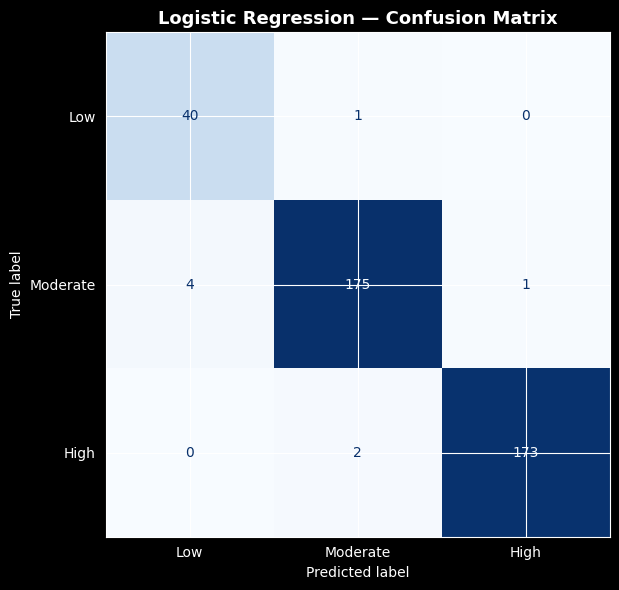

In [18]:
# Confusion matrix — Logistic Regression
fig, ax = plt.subplots(figsize=(7, 6))
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Low', 'Moderate', 'High'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Logistic Regression — Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cm_logistic_regression.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# Cross-validation — Logistic Regression
cv_lr = cross_val_score(
    lr_pipeline, X, y, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro'
)
print(f"📊 LR Cross-Val Macro F1 (5-fold): {cv_lr.mean():.4f} ± {cv_lr.std():.4f}")

📊 LR Cross-Val Macro F1 (5-fold): 0.9543 ± 0.0105


---
## 🌲 Section 6: Model Training — Random Forest (Primary Model)

In [20]:
# ─── 6.1 Build Random Forest Pipeline ─────────────────────────────────────────
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)
print("✅ Random Forest trained!")

✅ Random Forest trained!


In [21]:
# ─── 6.2 Evaluate Random Forest ───────────────────────────────────────────────
y_pred_rf = rf_pipeline.predict(X_test)

rf_report = classification_report(y_test, y_pred_rf, target_names=['Low', 'Moderate', 'High'])
rf_macro_f1    = f1_score(y_test, y_pred_rf, average='macro')
rf_weighted_f1 = f1_score(y_test, y_pred_rf, average='weighted')
rf_high_recall = recall_score(y_test, y_pred_rf, labels=[2], average='macro')
rf_accuracy    = accuracy_score(y_test, y_pred_rf)

print("=" * 60)
print("📊 RANDOM FOREST — Classification Report")
print("=" * 60)
print(rf_report)
print(f"Macro F1-Score:      {rf_macro_f1:.4f}")
print(f"Weighted F1-Score:   {rf_weighted_f1:.4f}")
print(f"High-Risk Recall:    {rf_high_recall:.4f}")
print(f"Accuracy:            {rf_accuracy:.4f}")

📊 RANDOM FOREST — Classification Report
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00        41
    Moderate       1.00      1.00      1.00       180
        High       1.00      1.00      1.00       175

    accuracy                           1.00       396
   macro avg       1.00      1.00      1.00       396
weighted avg       1.00      1.00      1.00       396

Macro F1-Score:      1.0000
Weighted F1-Score:   1.0000
High-Risk Recall:    1.0000
Accuracy:            1.0000


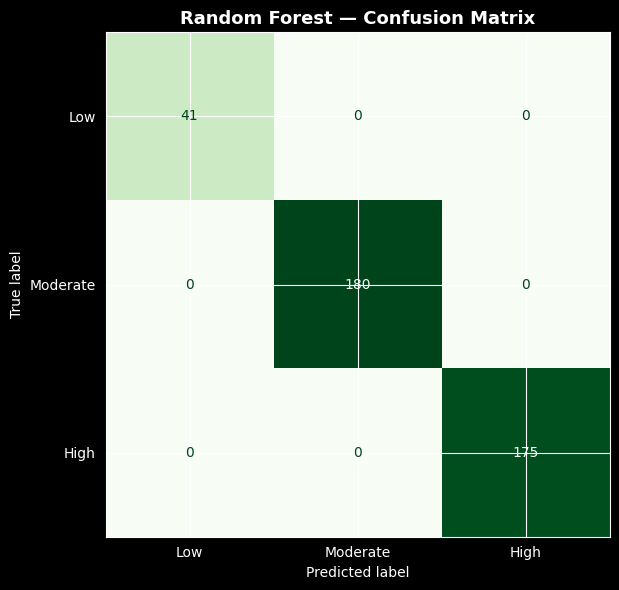

In [22]:
# Confusion matrix — Random Forest
fig, ax = plt.subplots(figsize=(7, 6))
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Low', 'Moderate', 'High'])
disp.plot(ax=ax, cmap='Greens', colorbar=False)
ax.set_title('Random Forest — Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cm_random_forest.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# Cross-validation — Random Forest
cv_rf = cross_val_score(
    rf_pipeline, X, y, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro'
)
print(f"📊 RF Cross-Val Macro F1 (5-fold): {cv_rf.mean():.4f} ± {cv_rf.std():.4f}")

📊 RF Cross-Val Macro F1 (5-fold): 0.9989 ± 0.0015


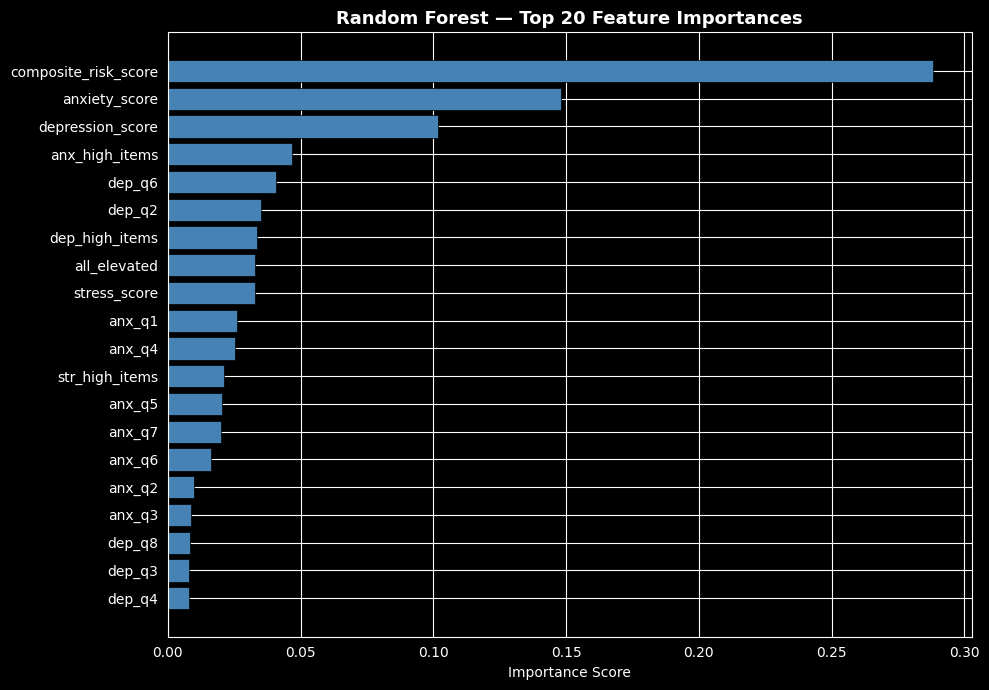

In [24]:
# Feature importance — Random Forest
rf_clf = rf_pipeline.named_steps['clf']
importances = rf_clf.feature_importances_
feat_imp_df = pd.DataFrame({'feature': FEATURES, 'importance': importances})
feat_imp_df = feat_imp_df.sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(feat_imp_df['feature'][::-1], feat_imp_df['importance'][::-1],
        color='steelblue', edgecolor='black', linewidth=0.5)
ax.set_title('Random Forest — Top 20 Feature Importances', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## ⚡ Section 7: Additional Models (Gradient Boosting & SVM)

In [25]:
# ─── 7.1 Gradient Boosting Classifier ─────────────────────────────────────────
gb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.1,
        max_depth=4,
        random_state=42
    ))
])

gb_pipeline.fit(X_train, y_train)
y_pred_gb = gb_pipeline.predict(X_test)

gb_macro_f1    = f1_score(y_test, y_pred_gb, average='macro')
gb_high_recall = recall_score(y_test, y_pred_gb, labels=[2], average='macro')

print("📊 GRADIENT BOOSTING — Classification Report")
print(classification_report(y_test, y_pred_gb, target_names=['Low', 'Moderate', 'High']))
print(f"Macro F1:         {gb_macro_f1:.4f}")
print(f"High-Risk Recall: {gb_high_recall:.4f}")

📊 GRADIENT BOOSTING — Classification Report
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00        41
    Moderate       1.00      1.00      1.00       180
        High       1.00      1.00      1.00       175

    accuracy                           1.00       396
   macro avg       1.00      1.00      1.00       396
weighted avg       1.00      1.00      1.00       396

Macro F1:         1.0000
High-Risk Recall: 1.0000


In [26]:
# ─── 7.2 Support Vector Machine ───────────────────────────────────────────────
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        class_weight='balanced',
        decision_function_shape='ovr',
        random_state=42,
        probability=True
    ))
])

svm_pipeline.fit(X_train, y_train)
y_pred_svm = svm_pipeline.predict(X_test)

svm_macro_f1    = f1_score(y_test, y_pred_svm, average='macro')
svm_high_recall = recall_score(y_test, y_pred_svm, labels=[2], average='macro')

print("📊 SVM — Classification Report")
print(classification_report(y_test, y_pred_svm, target_names=['Low', 'Moderate', 'High']))
print(f"Macro F1:         {svm_macro_f1:.4f}")
print(f"High-Risk Recall: {svm_high_recall:.4f}")

📊 SVM — Classification Report
              precision    recall  f1-score   support

         Low       0.85      1.00      0.92        41
    Moderate       0.97      0.93      0.95       180
        High       0.97      0.97      0.97       175

    accuracy                           0.95       396
   macro avg       0.93      0.97      0.95       396
weighted avg       0.96      0.95      0.95       396

Macro F1:         0.9463
High-Risk Recall: 0.9657


---
## 📊 Section 8: Model Comparison

In [27]:
# ─── 8.1 Comparison Table ─────────────────────────────────────────────────────
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'SVM'],
    'Macro F1': [
        round(lr_macro_f1, 4),
        round(rf_macro_f1, 4),
        round(gb_macro_f1, 4),
        round(svm_macro_f1, 4)
    ],
    'High-Risk Recall': [
        round(lr_high_recall, 4),
        round(rf_high_recall, 4),
        round(gb_high_recall, 4),
        round(svm_high_recall, 4)
    ],
    'Accuracy': [
        round(accuracy_score(y_test, y_pred_lr), 4),
        round(rf_accuracy, 4),
        round(accuracy_score(y_test, y_pred_gb), 4),
        round(accuracy_score(y_test, y_pred_svm), 4)
    ]
})

comparison['PRD Goal Met (Macro F1 ≥ 0.75)'] = comparison['Macro F1'].apply(
    lambda x: '✅ Yes' if x >= 0.75 else '❌ No'
)
comparison['PRD Goal Met (Recall ≥ 0.85)'] = comparison['High-Risk Recall'].apply(
    lambda x: '✅ Yes' if x >= 0.85 else '❌ No'
)

print("=" * 80)
print("📊 MODEL COMPARISON SUMMARY")
print("=" * 80)
print(comparison.to_string(index=False))

📊 MODEL COMPARISON SUMMARY
              Model  Macro F1  High-Risk Recall  Accuracy PRD Goal Met (Macro F1 ≥ 0.75) PRD Goal Met (Recall ≥ 0.85)
Logistic Regression    0.9701            0.9886    0.9798                          ✅ Yes                        ✅ Yes
      Random Forest    1.0000            1.0000    1.0000                          ✅ Yes                        ✅ Yes
  Gradient Boosting    1.0000            1.0000    1.0000                          ✅ Yes                        ✅ Yes
                SVM    0.9463            0.9657    0.9545                          ✅ Yes                        ✅ Yes


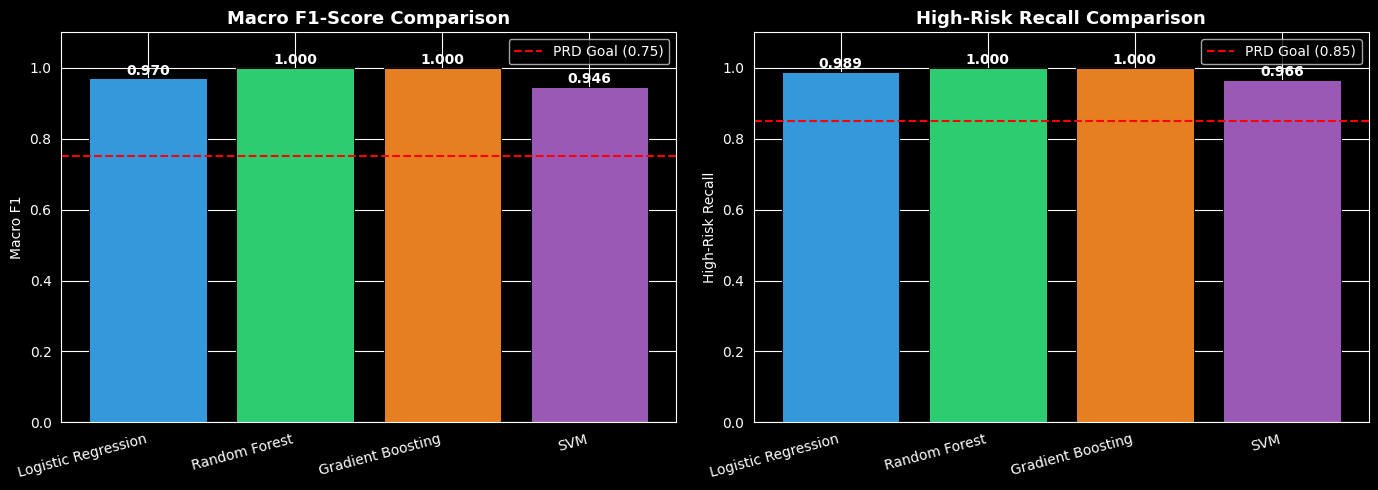

In [28]:
# ─── 8.2 Visual Comparison ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = comparison['Model']
x = np.arange(len(models))
bar_colors = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6']

axes[0].bar(x, comparison['Macro F1'], color=bar_colors, edgecolor='black', linewidth=0.7)
axes[0].axhline(y=0.75, color='red', linestyle='--', label='PRD Goal (0.75)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=15, ha='right')
axes[0].set_title('Macro F1-Score Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Macro F1')
axes[0].set_ylim(0, 1.1)
axes[0].legend()
for i, v in enumerate(comparison['Macro F1']):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

axes[1].bar(x, comparison['High-Risk Recall'], color=bar_colors, edgecolor='black', linewidth=0.7)
axes[1].axhline(y=0.85, color='red', linestyle='--', label='PRD Goal (0.85)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=15, ha='right')
axes[1].set_title('High-Risk Recall Comparison', fontsize=13, fontweight='bold')
axes[1].set_ylabel('High-Risk Recall')
axes[1].set_ylim(0, 1.1)
axes[1].legend()
for i, v in enumerate(comparison['High-Risk Recall']):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🔍 Section 9: SHAP Explainability

In [36]:
# ─── 9.1 SHAP for Random Forest (Primary Model) ───────────────────────────────
# Use scaled data (post-pipeline transform)
scaler_rf = rf_pipeline.named_steps['scaler']
X_train_scaled = scaler_rf.transform(X_train)
X_test_scaled  = scaler_rf.transform(X_test)

X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=FEATURES)

# Fit SHAP TreeExplainer
explainer_rf = shap.TreeExplainer(rf_clf)
shap_values_rf = explainer_rf.shap_values(X_test_scaled_df)

# Handle SHAP values format for multi-class
if isinstance(shap_values_rf, list):
    # SHAP returns list of arrays for multi-class: [class0_values, class1_values, class2_values]
    print(f"✅ SHAP values computed for Random Forest (list format)")
    print(f"   Number of classes: {len(shap_values_rf)}")
    print(f"   SHAP values per class shape: {shap_values_rf[0].shape}")
else:
    # SHAP returns single array: [samples, features, classes]
    print(f"✅ SHAP values computed for Random Forest (array format)")
    print(f"   SHAP values shape: {shap_values_rf.shape}")
    # Convert to list format for easier handling
    shap_values_rf = [shap_values_rf[:, :, i] for i in range(shap_values_rf.shape[2])]
    print(f"   Converted to list format: {len(shap_values_rf)} classes")

✅ SHAP values computed for Random Forest (array format)
   SHAP values shape: (396, 43, 3)
   Converted to list format: 3 classes


🔍 SHAP Summary Plot — High Risk Class (Class 2)


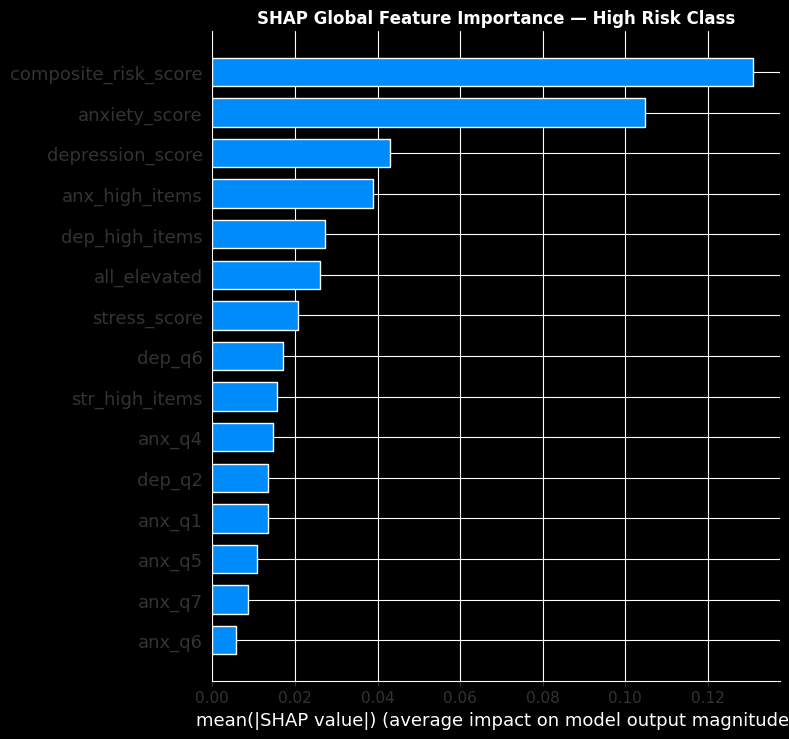

In [37]:
# ─── 9.2 Global SHAP Summary — High Risk Class ────────────────────────────────
print("🔍 SHAP Summary Plot — High Risk Class (Class 2)")

# Use the correct SHAP values format
shap_values_high_risk = shap_values_rf[2] if isinstance(shap_values_rf, list) else shap_values_rf[:, :, 2]

shap.summary_plot(
    shap_values_high_risk,
    X_test_scaled_df,
    plot_type='bar',
    show=False,
    max_display=15
)
plt.title('SHAP Global Feature Importance — High Risk Class', fontweight='bold')
plt.tight_layout()
plt.show()

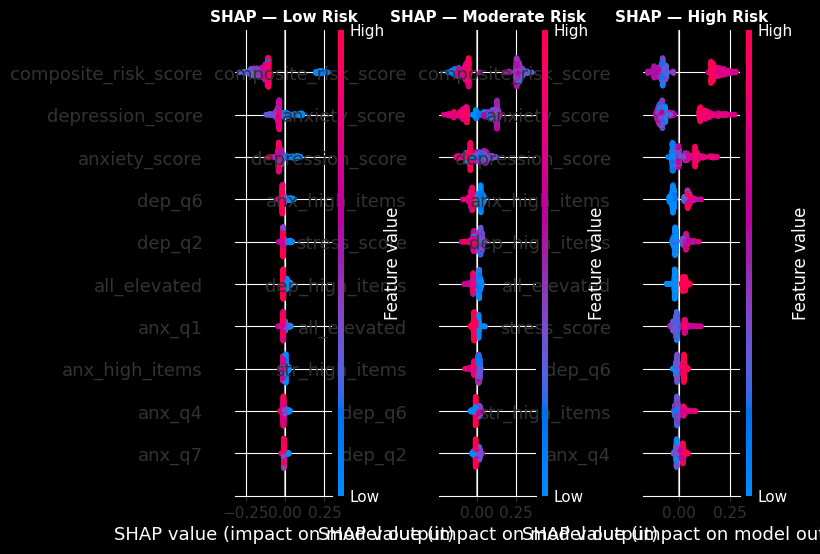

In [47]:
# ─── 9.3 SHAP Beeswarm — All Classes ─────────────────────────────────────────
class_names = ['Low Risk', 'Moderate Risk', 'High Risk']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for i, (ax, class_name) in enumerate(zip(axes, class_names)):
    plt.sca(ax)

    # Get correct SHAP values for this class
    shap_values_class = shap_values_rf[i] if isinstance(shap_values_rf, list) else shap_values_rf[:, :, i]

    shap.summary_plot(
        shap_values_class,
        X_test_scaled_df,
        show=False,
        max_display=10
    )
    ax.set_title(f'SHAP — {class_name}', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

📌 Student Index: 0
📌 Predicted Class: High
📌 Probabilities — Low: 0.000 | Moderate: 0.000 | High: 1.000


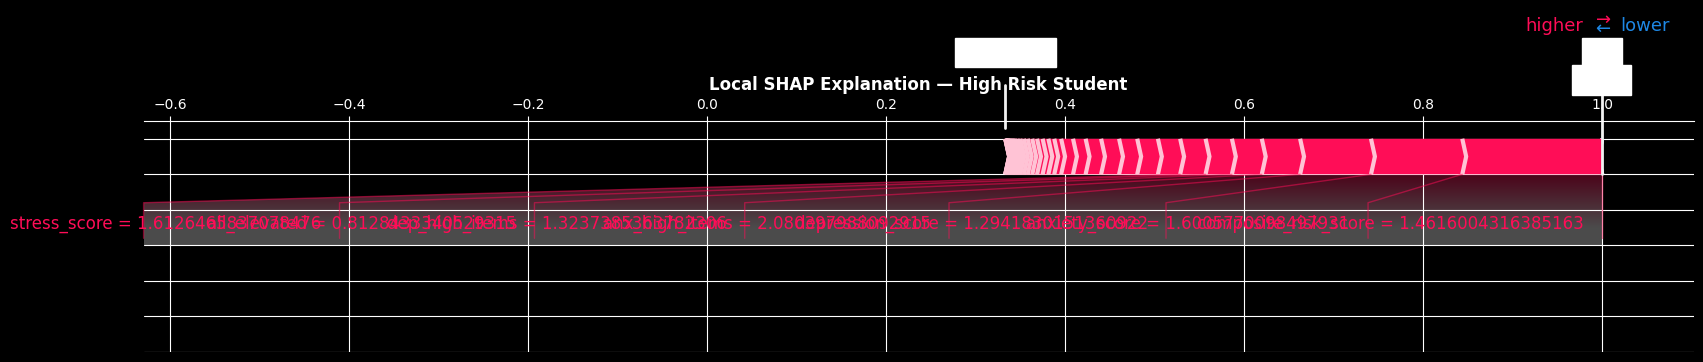

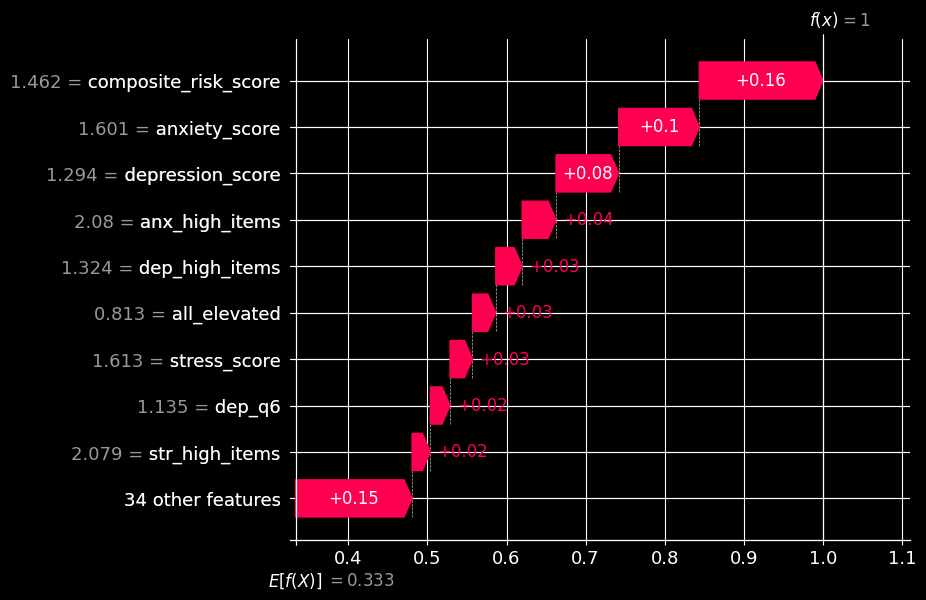

In [49]:
# ─── 9.4 Local SHAP Explanation — Individual Prediction ──────────────────────

# Pick first High-Risk student in test set
high_risk_indices = np.where(y_test.values == 2)[0]

if len(high_risk_indices) > 0:
    sample_idx = high_risk_indices[0]

    sample_raw = X_test.iloc[[sample_idx]]
    sample_scaled = X_test_scaled_df.iloc[[sample_idx]]

    pred_class = rf_pipeline.predict(sample_raw)[0]
    pred_proba = rf_pipeline.predict_proba(sample_raw)[0]

    print(f"📌 Student Index: {sample_idx}")
    print(f"📌 Predicted Class: {risk_map[pred_class]}")
    print(f"📌 Probabilities — Low: {pred_proba[0]:.3f} | Moderate: {pred_proba[1]:.3f} | High: {pred_proba[2]:.3f}")

    # ─── Extract SHAP values correctly for multi-class ───
    if isinstance(shap_values_rf, list):
        shap_values_high = shap_values_rf[2]
        base_value = explainer_rf.expected_value[2]
    else:
        shap_values_high = shap_values_rf[:, :, 2]
        base_value = explainer_rf.expected_value[2]

    # ─── Force Plot (NEW API) ───
    shap.plots.force(
        base_value,
        shap_values_high[sample_idx],
        sample_scaled.iloc[0],   # must be 1D
        matplotlib=True,
        show=False
    )

    plt.title('Local SHAP Explanation — High Risk Student', fontweight='bold')
    plt.savefig('shap_local_high_risk.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ─── Optional: Waterfall Plot (more stable in new SHAP) ───
    shap.plots.waterfall(
        shap.Explanation(
            values=shap_values_high[sample_idx],
            base_values=base_value,
            data=sample_scaled.iloc[0],
            feature_names=sample_scaled.columns
        )
    )

else:
    print("⚠️ No High-Risk students found in test set.")

In [44]:
# ─── 9.5 Top Contributing Features — Human-Readable ──────────────────────────
def get_top_shap_features(shap_vals, feature_names, class_idx, top_n=5):
    """Return top N features driving a specific class prediction."""
    mean_abs_shap = np.abs(shap_vals[class_idx]).mean(axis=0)
    top_idx = np.argsort(mean_abs_shap)[::-1][:top_n]
    return [(feature_names[i], round(float(mean_abs_shap[i]), 4)) for i in top_idx]

print("\n🔍 Top 5 Features Driving HIGH RISK Predictions:")
for feat, score in get_top_shap_features(shap_values_rf, FEATURES, class_idx=2):
    print(f"   {feat}: {score}")

print("\n🔍 Top 5 Features Driving MODERATE RISK Predictions:")
for feat, score in get_top_shap_features(shap_values_rf, FEATURES, class_idx=1):
    print(f"   {feat}: {score}")

print("\n🔍 Top 5 Features Driving LOW RISK Predictions:")
for feat, score in get_top_shap_features(shap_values_rf, FEATURES, class_idx=0):
    print(f"   {feat}: {score}")


🔍 Top 5 Features Driving HIGH RISK Predictions:
   composite_risk_score: 0.1309
   anxiety_score: 0.1048
   depression_score: 0.0431
   anx_high_items: 0.0388
   dep_high_items: 0.0273

🔍 Top 5 Features Driving MODERATE RISK Predictions:
   composite_risk_score: 0.1706
   anxiety_score: 0.0946
   depression_score: 0.0448
   anx_high_items: 0.0281
   stress_score: 0.023

🔍 Top 5 Features Driving LOW RISK Predictions:
   composite_risk_score: 0.1543
   depression_score: 0.0453
   anxiety_score: 0.0365
   dep_q6: 0.0178
   dep_q2: 0.0147


---
## 🧪 Section 10: MLflow Experiment Tracking

In [ ]:
# ─── 10.1 Set up MLflow ────────────────────────────────────────────────────────
mlflow.set_tracking_uri('mlruns')  # local tracking
mlflow.set_experiment('student_mental_health_risk')

print("✅ MLflow configured. Tracking URI: mlruns")

In [ ]:
# ─── 10.2 Log All Models to MLflow ────────────────────────────────────────────

model_registry = [
    {
        'name': 'logistic_regression',
        'pipeline': lr_pipeline,
        'y_pred': y_pred_lr,
        'params': {'C': 1.0, 'max_iter': 1000, 'solver': 'lbfgs', 'class_weight': 'balanced'},
    },
    {
        'name': 'random_forest',
        'pipeline': rf_pipeline,
        'y_pred': y_pred_rf,
        'params': {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 2,
                   'class_weight': 'balanced'},
    },
    {
        'name': 'gradient_boosting',
        'pipeline': gb_pipeline,
        'y_pred': y_pred_gb,
        'params': {'n_estimators': 150, 'learning_rate': 0.1, 'max_depth': 4},
    },
    {
        'name': 'svm',
        'pipeline': svm_pipeline,
        'y_pred': y_pred_svm,
        'params': {'kernel': 'rbf', 'C': 1.0, 'gamma': 'scale', 'class_weight': 'balanced'},
    },
]

for entry in model_registry:
    with mlflow.start_run(run_name=entry['name']):
        # Log parameters
        mlflow.log_params(entry['params'])

        # Compute metrics
        macro_f1    = f1_score(y_test, entry['y_pred'], average='macro')
        weighted_f1 = f1_score(y_test, entry['y_pred'], average='weighted')
        high_recall = recall_score(y_test, entry['y_pred'], labels=[2], average='macro')
        acc         = accuracy_score(y_test, entry['y_pred'])

        # Log metrics
        mlflow.log_metric('macro_f1', macro_f1)
        mlflow.log_metric('weighted_f1', weighted_f1)
        mlflow.log_metric('high_risk_recall', high_recall)
        mlflow.log_metric('accuracy', acc)

        # Log model
        mlflow.sklearn.log_model(
            entry['pipeline'],
            artifact_path='model',
            registered_model_name=f'mental_health_{entry["name"]}'
        )

        print(f"✅ Logged: {entry['name']} | Macro F1: {macro_f1:.4f} | High-Risk Recall: {high_recall:.4f}")

print("\n🎯 All models logged to MLflow!")
print("   Run: mlflow ui  to view the experiment dashboard")

---
## 💾 Section 11: Model Export & Deployment Pipeline

In [ ]:
# ─── 11.1 Select Best Model Based on PRD Goals ────────────────────────────────
# PRD Goals: Macro F1 >= 0.75  AND  High-Risk Recall >= 0.85

all_metrics = {
    'logistic_regression': {'macro_f1': lr_macro_f1, 'high_recall': lr_high_recall},
    'random_forest':       {'macro_f1': rf_macro_f1, 'high_recall': rf_high_recall},
    'gradient_boosting':   {'macro_f1': gb_macro_f1, 'high_recall': gb_high_recall},
    'svm':                 {'macro_f1': svm_macro_f1, 'high_recall': svm_high_recall},
}

# Priority: High-Risk Recall first, then Macro F1
best_model_name = max(
    all_metrics,
    key=lambda m: (all_metrics[m]['high_recall'], all_metrics[m]['macro_f1'])
)

pipeline_map = {
    'logistic_regression': lr_pipeline,
    'random_forest': rf_pipeline,
    'gradient_boosting': gb_pipeline,
    'svm': svm_pipeline
}

best_pipeline = pipeline_map[best_model_name]

print(f"🏆 Best Model Selected: {best_model_name}")
print(f"   Macro F1:         {all_metrics[best_model_name]['macro_f1']:.4f}")
print(f"   High-Risk Recall: {all_metrics[best_model_name]['high_recall']:.4f}")

In [ ]:
# ─── 11.2 Save Models & Artifacts ─────────────────────────────────────────────
os.makedirs('models', exist_ok=True)

# Save all models
joblib.dump(lr_pipeline, 'models/logistic_regression_pipeline.pkl')
joblib.dump(rf_pipeline, 'models/random_forest_pipeline.pkl')
joblib.dump(gb_pipeline, 'models/gradient_boosting_pipeline.pkl')
joblib.dump(svm_pipeline, 'models/svm_pipeline.pkl')

# Save best model with a standard name for API use
joblib.dump(best_pipeline, 'models/production_model.pkl')

# Save feature list and label map for API
model_metadata = {
    'features': FEATURES,
    'target': TARGET,
    'label_map': risk_map,
    'best_model': best_model_name,
    'n_features': len(FEATURES),
    'classes': [0, 1, 2],
    'class_names': ['Low', 'Moderate', 'High'],
    'prd_metrics': {
        'macro_f1_goal': 0.75,
        'high_risk_recall_goal': 0.85,
        'best_macro_f1': round(all_metrics[best_model_name]['macro_f1'], 4),
        'best_high_risk_recall': round(all_metrics[best_model_name]['high_recall'], 4)
    }
}

with open('models/model_metadata.json', 'w') as f:
    json.dump(model_metadata, f, indent=2)

print("✅ All models saved to ./models/")
print("   - logistic_regression_pipeline.pkl")
print("   - random_forest_pipeline.pkl")
print("   - gradient_boosting_pipeline.pkl")
print("   - svm_pipeline.pkl")
print("   - production_model.pkl  (best model)")
print("   - model_metadata.json")

In [ ]:
# ─── 11.3 Unified Prediction Function (for FastAPI integration) ───────────────

def predict_risk(input_dict: dict, model_path: str = 'models/production_model.pkl') -> dict:
    """
    Unified prediction function for FastAPI integration.
    
    Args:
        input_dict: Dictionary of feature_name → value
        model_path: Path to the serialized pipeline
    
    Returns:
        dict with risk_class, risk_label, probabilities, and top_features
    """
    pipeline = joblib.load(model_path)
    
    # Validate features
    with open('models/model_metadata.json') as f:
        meta = json.load(f)
    
    feature_names = meta['features']
    input_df = pd.DataFrame([{feat: input_dict.get(feat, 0) for feat in feature_names}])
    
    # Predict
    pred_class = int(pipeline.predict(input_df)[0])
    pred_proba = pipeline.predict_proba(input_df)[0].tolist()
    
    return {
        'risk_class': pred_class,
        'risk_label': meta['label_map'][str(pred_class)],
        'probabilities': {
            'Low': round(pred_proba[0], 4),
            'Moderate': round(pred_proba[1], 4),
            'High': round(pred_proba[2], 4)
        }
    }


# Quick test
sample_input = {feat: float(X_test.iloc[0][feat]) for feat in FEATURES}
result = predict_risk(sample_input)
print("🧪 Test Prediction:")
print(f"   Risk Label:    {result['risk_label']}")
print(f"   Probabilities: {result['probabilities']}")

In [ ]:
# ─── 11.4 Batch Prediction Function (for CSV upload feature) ──────────────────

def batch_predict(csv_path: str, model_path: str = 'models/production_model.pkl') -> pd.DataFrame:
    """
    Batch predict risk for a CSV file of student data.
    Used by the web dashboard CSV upload feature.
    """
    pipeline = joblib.load(model_path)

    with open('models/model_metadata.json') as f:
        meta = json.load(f)

    batch_df = pd.read_csv(csv_path)
    feature_names = meta['features']

    # Ensure all features are present
    for feat in feature_names:
        if feat not in batch_df.columns:
            batch_df[feat] = 0

    X_batch = batch_df[feature_names].fillna(0)
    preds = pipeline.predict(X_batch)
    probas = pipeline.predict_proba(X_batch)

    batch_df['predicted_risk_class'] = preds
    batch_df['predicted_risk_label'] = [meta['label_map'][str(p)] for p in preds]
    batch_df['prob_low']      = probas[:, 0].round(4)
    batch_df['prob_moderate'] = probas[:, 1].round(4)
    batch_df['prob_high']     = probas[:, 2].round(4)

    return batch_df[[
        'predicted_risk_label', 'predicted_risk_class',
        'prob_low', 'prob_moderate', 'prob_high'
    ]]


print("✅ batch_predict() function ready for FastAPI CSV endpoint")

---
## 📈 Section 12: Final Summary

In [ ]:
# ─── 12.1 Final Summary Dashboard ─────────────────────────────────────────────
print("=" * 70)
print("  🧠 STUDENT MENTAL HEALTH RISK PREDICTION — TRAINING SUMMARY")
print("=" * 70)
print(f"  Dataset:           {df_clean.shape[0]} students, {len(FEATURES)} features")
print(f"  Train / Test:      {X_train.shape[0]} / {X_test.shape[0]} samples")
print(f"  Target Classes:    Low (0) | Moderate (1) | High (2)")
print()
print("  📊 MODEL RESULTS")
print("-" * 70)
print(f"  {'Model':<25} {'Macro F1':>12} {'High Recall':>14} {'Accuracy':>12}")
print("-" * 70)
for _, row in comparison.iterrows():
    print(f"  {row['Model']:<25} {row['Macro F1']:>12.4f} {row['High-Risk Recall']:>14.4f} {row['Accuracy']:>12.4f}")
print("-" * 70)
print()
print(f"  🏆 Production Model:  {best_model_name}")
print(f"  ✅ PRD Goal (F1≥0.75): {'MET' if all_metrics[best_model_name]['macro_f1'] >= 0.75 else 'NOT MET'}")
print(f"  ✅ PRD Goal (Recall≥0.85): {'MET' if all_metrics[best_model_name]['high_recall'] >= 0.85 else 'NOT MET'}")
print()
print("  💾 Saved Artifacts")
print("     ./models/production_model.pkl")
print("     ./models/model_metadata.json")
print("     ./mlruns/  (MLflow experiments)")
print("=" * 70)

---
## 📝 Notes for FastAPI Integration

Load the production model in your FastAPI app like this:

```python
import joblib, json, pandas as pd

pipeline = joblib.load('models/production_model.pkl')

with open('models/model_metadata.json') as f:
    meta = json.load(f)

@app.post('/predict')
def predict(data: StudentInput):
    input_df = pd.DataFrame([data.dict()])[meta['features']]
    pred = pipeline.predict(input_df)[0]
    proba = pipeline.predict_proba(input_df)[0]
    return {
        'risk_class': int(pred),
        'risk_label': meta['label_map'][str(pred)],
        'probabilities': dict(zip(meta['class_names'], proba.tolist()))
    }
```

To swap the production model via MLflow registry, load from MLflow instead:

```python
import mlflow.sklearn
pipeline = mlflow.sklearn.load_model('models:/mental_health_random_forest/Production')
```

---
⚠️ **Ethical Disclaimer:** This system is for early risk screening only. It is NOT a clinical diagnostic tool. Predictions should be reviewed by qualified counsellors and must not replace professional mental health assessment.